In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv')
test_data = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv')
validation_data = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv')


if 'plots' not in os.listdir():
    os.mkdir('plots')

/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/sample_submission.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv


In [2]:
import torch
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)                   # Python random module
    np.random.seed(seed)                 # NumPy
    torch.manual_seed(seed)              # PyTorch CPU
    torch.cuda.manual_seed(seed)         # PyTorch GPU
    torch.cuda.manual_seed_all(seed)     # If you use multi-GPU
    torch.backends.cudnn.deterministic = True  # Make CUDA deterministic
    torch.backends.cudnn.benchmark = False     # Disable optimization for speed (forces deterministic)

set_seed(42)

In [3]:
train_data

,ID,Text,Label
0,189385,@whoisralphie dude I'm so bummed ur leaving!,0
1,58036,"oh my god, a severed foot was foun in a wheely...",0
2,190139,I end up &quot;dog dialing&quot; sumtimes. Wha...,1
3,99313,@_rachelx meeeee toooooo!,0
4,157825,"I was hoping I could stay home and work today,...",0
...,...,...,...
148383,99894,just love the jonas brothers its tooo bad i w...,0
148384,61015,another day gone by....time is moving so fast...,0
148385,36598,"fuck college, i'm just gonna marry rich. : fuc...",1
148386,83799,ZOMGZ NEW SONG FTW. remember that night. &lt;3,1


In [4]:
import html
import re

# Function to preprocess text
def preprocess_text(text):
    # Unescape HTML characters
    text = html.unescape(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Function to preprocess text
def preprocess_text2(text):
    # Unescape HTML characters
    text = html.unescape(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '<url>', text)
    # Remove mentions
    text = re.sub(r'@\w+', '<user>', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '<hashtag>', text)
    # Remove special characters and numbers except < and >
    # text = re.sub(r'[^a-zA-Z0-9\s<>]', '', text)
    # text = re.sub(r'[^a-zA-Z0-9\s<>\.\,\!\?\:\;\'\"]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing to train, test, and validation datasets
train_data['Clean'] = train_data['Text'].apply(preprocess_text)
test_data['Clean'] = test_data['Text'].apply(preprocess_text)
validation_data['Clean'] = validation_data['Text'].apply(preprocess_text)

# Apply preprocessing to train, test, and validation datasets
train_data['Clean2'] = train_data['Text'].apply(preprocess_text2)
test_data['Clean2'] = test_data['Text'].apply(preprocess_text2)
validation_data['Clean2'] = validation_data['Text'].apply(preprocess_text2)

# Display a sample of the cleaned text
train_data[['Text', 'Clean', 'Clean2']]

,Text,Clean,Clean2
0,@whoisralphie dude I'm so bummed ur leaving!,whoisralphie dude im so bummed ur leaving,<user> dude I'm so bummed ur leaving!
1,"oh my god, a severed foot was foun in a wheely...",oh my god a severed foot was foun in a wheely ...,"oh my god, a severed foot was foun in a wheely..."
2,I end up &quot;dog dialing&quot; sumtimes. Wha...,i end up dog dialing sumtimes whats dog dialin...,"I end up ""dog dialing"" sumtimes. What's dog di..."
3,@_rachelx meeeee toooooo!,rachelx meeeee toooooo,<user> meeeee toooooo!
4,"I was hoping I could stay home and work today,...",i was hoping i could stay home and work today ...,"I was hoping I could stay home and work today,..."
...,...,...,...
148383,just love the jonas brothers its tooo bad i w...,just love the jonas brothers its tooo bad i wi...,just love the jonas brothers its tooo bad i wi...
148384,another day gone by....time is moving so fast...,another day gone bytime is moving so fast,another day gone by....time is moving so fast...
148385,"fuck college, i'm just gonna marry rich. : fuc...",fuck college im just gonna marry rich fuck col...,"fuck college, i'm just gonna marry rich. : fuc..."
148386,ZOMGZ NEW SONG FTW. remember that night. &lt;3,zomgz new song ftw remember that night,ZOMGZ NEW SONG FTW. remember that night. <3


In [5]:
from nltk.tokenize import TweetTokenizer

tknzr = TweetTokenizer(preserve_case=False)

def tokenize_text(text):
    return tknzr.tokenize(text)

train_data['Tokenized'] = train_data['Clean'].apply(tokenize_text)
test_data['Tokenized'] = test_data['Clean'].apply(tokenize_text)
validation_data['Tokenized'] = validation_data['Clean'].apply(tokenize_text)

train_data['Tokenized2'] = train_data['Clean2'].apply(tokenize_text)
test_data['Tokenized2'] = test_data['Clean2'].apply(tokenize_text)
validation_data['Tokenized2'] = validation_data['Clean2'].apply(tokenize_text)

train_data[['Text', 'Tokenized', 'Tokenized2']]

,Text,Tokenized,Tokenized2
0,@whoisralphie dude I'm so bummed ur leaving!,"[whoisralphie, dude, im, so, bummed, ur, leaving]","[<user>, dude, i'm, so, bummed, ur, leaving, !]"
1,"oh my god, a severed foot was foun in a wheely...","[oh, my, god, a, severed, foot, was, foun, in,...","[oh, my, god, ,, a, severed, foot, was, foun, ..."
2,I end up &quot;dog dialing&quot; sumtimes. Wha...,"[i, end, up, dog, dialing, sumtimes, whats, do...","[i, end, up, "", dog, dialing, "", sumtimes, ., ..."
3,@_rachelx meeeee toooooo!,"[rachelx, meeeee, toooooo]","[<user>, meeeee, toooooo, !]"
4,"I was hoping I could stay home and work today,...","[i, was, hoping, i, could, stay, home, and, wo...","[i, was, hoping, i, could, stay, home, and, wo..."
...,...,...,...
148383,just love the jonas brothers its tooo bad i w...,"[just, love, the, jonas, brothers, its, tooo, ...","[just, love, the, jonas, brothers, its, tooo, ..."
148384,another day gone by....time is moving so fast...,"[another, day, gone, bytime, is, moving, so, f...","[another, day, gone, by, ..., time, is, moving..."
148385,"fuck college, i'm just gonna marry rich. : fuc...","[fuck, college, im, just, gonna, marry, rich, ...","[fuck, college, ,, i'm, just, gonna, marry, ri..."
148386,ZOMGZ NEW SONG FTW. remember that night. &lt;3,"[zomgz, new, song, ftw, remember, that, night]","[zomgz, new, song, ftw, ., remember, that, nig..."


In [6]:
import os

if 'glove.twitter.27B.zip' not in os.listdir():
    !wget https://nlp.stanford.edu/data/glove.twitter.27B.zip
else:
    print('Embeddings already downloaded!')
if 'glove.twitter.27B.50d.txt' not in os.listdir():
    !unzip glove*.zip
else:
    print('Embeddings already unzipped!')

--2025-04-30 22:05:03--  https://nlp.stanford.edu/data/glove.twitter.27B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip [following]
--2025-04-30 22:05:03--  https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1520408563 (1.4G) [application/zip]
Saving to: ‘glove.twitter.27B.zip’

glove.twitter.27B.z 100%[===================>]   1.42G  5.02MB/s    in 4m 45s  

2025-04-30 22:09:48 (5.09 MB/s) - ‘glove.twitter.27B.zip’ saved [1520408563/1520408563]

Archive:  glove.twitter.27B.zip
  inflating: glove.twitter.27

In [7]:
from gensim.models import KeyedVectors

glove_input_file = 'glove.twitter.27B.200d.txt'

model = KeyedVectors.load_word2vec_format(glove_input_file, binary=False, no_header=True)

def index_tweet_tokens(tokens):
    indices = []
    for token in tokens:
        if token in model.key_to_index:
            indices.append(model.key_to_index[token])
        else:
            indices.append(0)
    return indices

train_data['Indices'] = train_data['Tokenized'].apply(index_tweet_tokens)
test_data['Indices'] = test_data['Tokenized'].apply(index_tweet_tokens)
validation_data['Indices'] = validation_data['Tokenized'].apply(index_tweet_tokens)

train_data['Indices2'] = train_data['Tokenized2'].apply(index_tweet_tokens)
test_data['Indices2'] = test_data['Tokenized2'].apply(index_tweet_tokens)
validation_data['Indices2'] = validation_data['Tokenized2'].apply(index_tweet_tokens)


In [8]:
print(train_data[['Text', 'Tokenized', 'Tokenized2', 'Indices']].tail())

                                                     Text  \
148383  just love the jonas brothers  its tooo bad i w...   
148384  another day gone by....time is moving so fast...    
148385  fuck college, i'm just gonna marry rich. : fuc...   
148386    ZOMGZ NEW SONG FTW.  remember that night. &lt;3   
148387  http://twitpic.com/7mwrd - Arby's took down th...   

                                                Tokenized  \
148383  [just, love, the, jonas, brothers, its, tooo, ...   
148384  [another, day, gone, bytime, is, moving, so, f...   
148385  [fuck, college, im, just, gonna, marry, rich, ...   
148386     [zomgz, new, song, ftw, remember, that, night]   
148387  [arbys, took, down, their, roastburger, coupon...   

                                               Tokenized2  \
148383  [just, love, the, jonas, brothers, its, tooo, ...   
148384  [another, day, gone, by, ..., time, is, moving...   
148385  [fuck, college, ,, i'm, just, gonna, marry, ri...   
148386  [zomgz, new, s

In [9]:
train_data.iloc[148386][['Tokenized', 'Indices']].values

array([list(['zomgz', 'new', 'song', 'ftw', 'remember', 'that', 'night']),
       list([0, 122, 524, 16483, 626, 45, 235])], dtype=object)

In [10]:
train_data.iloc[148386][['Tokenized2', 'Indices2']].values

array([list(['zomgz', 'new', 'song', 'ftw', '.', 'remember', 'that', 'night', '.', '<3']),
       list([0, 122, 524, 16483, 1, 626, 45, 235, 1, 0])], dtype=object)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

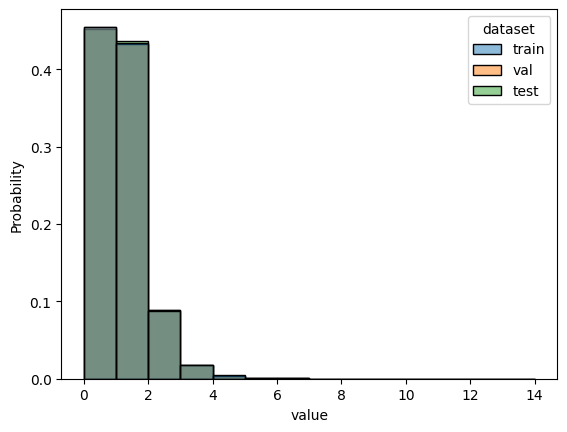

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

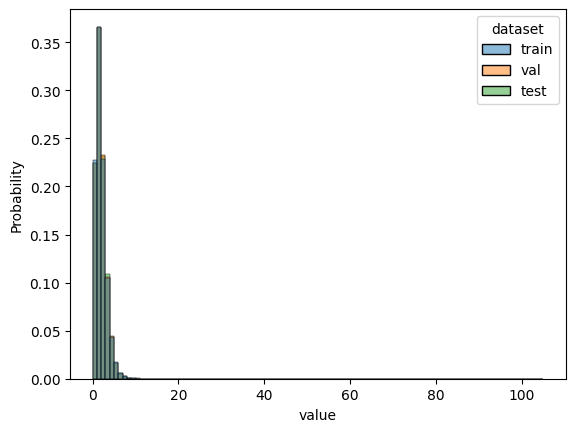

In [11]:
def count_zero_embeddings(indices):
    count = 0
    for index in indices:
        if index == 0:
            count += 1
    return count

# old pre-processing
train_zero_embeddings = train_data['Indices'].apply(count_zero_embeddings)
validation_zero_embeddings = validation_data['Indices'].apply(count_zero_embeddings)
test_zero_embeddings = test_data['Indices'].apply(count_zero_embeddings)

zero_embed_data = pd.DataFrame({
    'value': train_zero_embeddings.tolist() + validation_zero_embeddings.tolist() + test_zero_embeddings.tolist(),
    'dataset': ['train'] * len(train_zero_embeddings) + ['val'] * len(validation_zero_embeddings) + ['test'] * len(test_zero_embeddings)
})
sns.histplot(zero_embed_data, x='value', hue='dataset', stat='probability', binwidth=1, common_norm=False)
plt.show()

# new pre-processing
train_zero_embeddings = train_data['Indices2'].apply(count_zero_embeddings)
validation_zero_embeddings = validation_data['Indices2'].apply(count_zero_embeddings)
test_zero_embeddings = test_data['Indices2'].apply(count_zero_embeddings)

zero_embed_data = pd.DataFrame({
    'value': train_zero_embeddings.tolist() + validation_zero_embeddings.tolist() + test_zero_embeddings.tolist(),
    'dataset': ['train'] * len(train_zero_embeddings) + ['val'] * len(validation_zero_embeddings) + ['test'] * len(test_zero_embeddings)
})
sns.histplot(zero_embed_data, x='value', hue='dataset', stat='probability', binwidth=1, common_norm=False)
plt.show()

In [12]:
import torch
from torch import nn


vocab = model.index_to_key
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
weights_matrix = torch.zeros((len(vocab), model.vector_size))
for i, word in enumerate(vocab):
    weights_matrix[i] = torch.tensor(model[word])

embedding_layer = nn.Embedding.from_pretrained(weights_matrix, freeze=True)
embedding_layer

Embedding(1193514, 200)

In [13]:
embedding_layer(torch.tensor([model.key_to_index['hi']]))

tensor([[ 0.4352,  0.3099, -0.0943, -0.2237, -0.9643, -0.1043,  0.0902,  0.1498,
         -0.4590, -0.6484, -0.0366, -0.3369, -0.3003, -0.0404, -0.1630,  0.1103,
          0.0858, -0.1009, -0.0814, -0.3627,  0.2957, -0.1013, -0.1211, -0.0085,
         -0.6838, -0.0874,  0.6342, -0.0218,  0.1191, -0.0887,  0.6208, -0.0133,
         -0.3782,  0.6281, -0.0210,  0.5205, -0.4899,  0.2887, -0.3845,  0.3068,
         -0.4825,  0.0874, -0.6063,  0.0915, -0.2682, -0.0590,  0.0569, -0.4096,
          0.2042, -0.0901,  0.2570,  0.0065, -0.2279,  0.0372,  0.6275, -0.0551,
          0.8587,  0.0528,  0.1016, -0.3349,  0.1044,  0.1332,  0.2231, -0.5106,
         -0.1785,  0.5542, -0.3648,  0.5512, -0.2103, -0.2394,  0.6945, -0.4022,
          0.6744, -0.5999, -0.4463,  0.5644,  0.3892, -0.2292, -0.2666,  0.5895,
          0.2162,  0.2882, -0.5565, -0.5203,  0.1226, -0.5098, -0.3801,  0.4497,
          0.5526, -0.7060,  0.2121, -0.6118,  0.0302,  0.3100, -0.4703, -0.4324,
         -0.0878,  0.0102,  

In [14]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


class TweetDataset(Dataset):
    def __init__(self, tweets, labels, word_to_idx):
        self.tokenizer = TweetTokenizer(preserve_case=False)
        self.tweets = tweets
        self.labels = labels
        self.word_to_idx = word_to_idx

    def __len__(self):
        return len(self.tweets)

    def __getitem__(self, idx):
        tweet = self.tweets[idx]
        label = self.labels[idx]

        tokens = self.tokenizer.tokenize(tweet)
        indices = [self.word_to_idx.get(token, 0) for token in tokens]
        return torch.tensor(indices).int(), torch.tensor(label)

def pad_batch(batch):
    inputs, labels = zip(*batch)
    inputs = pad_sequence(inputs, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return inputs, labels

In [15]:
train_dataset = TweetDataset(train_data['Clean'], train_data['Label'], word_to_idx)
train_loader = DataLoader(train_dataset, batch_size=256, collate_fn=pad_batch, shuffle=True)
val_dataset = TweetDataset(validation_data['Clean'], validation_data['Label'], word_to_idx)
val_loader = DataLoader(val_dataset, batch_size=256, collate_fn=pad_batch)

train_dataset2 = TweetDataset(train_data['Clean2'], train_data['Label'], word_to_idx)
train_loader2 = DataLoader(train_dataset2, batch_size=256, collate_fn=pad_batch, shuffle=True)
val_dataset2 = TweetDataset(validation_data['Clean2'], validation_data['Label'], word_to_idx)
val_loader2 = DataLoader(val_dataset2, batch_size=256, collate_fn=pad_batch)

In [16]:
for inputs, labels in train_dataset:
    print(inputs.shape)
    print(labels.shape)
    break

torch.Size([7])
torch.Size([])


In [17]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [18]:
import torch.optim as optim

class MLP1(nn.Module):
    def __init__(self, embedding_layer, embedding_dim, hidden_dim, output_dim):
        super(MLP1, self).__init__()
        self.embedding = embedding_layer
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)  # Only 1 output neuron

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)  # (batch_size, seq_len, embedding_dim)
        pooled = embedded.mean(dim=1)          # (batch_size, embedding_dim)
        x = torch.relu(self.fc1(pooled))
        output = self.fc2(x)
        return output  # No activation here, we apply sigmoid in the loss function

# Instantiate model
embedding_dim = model.vector_size
hidden_dim = 128
output_dim = 1  # e.g., 2 classes: positive / negative

In [19]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, data_loader, device):
    model.eval()
    val_loss = 0
    y_proba = []
    y_pred = []
    y_true = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            val_loss += loss.item()

            proba = torch.sigmoid(outputs.squeeze())
            y_proba.extend(proba.cpu().numpy())
            preds = (proba > 0.5).float()
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    return val_loss / len(data_loader), y_true, y_pred, y_proba

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, device, n_epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    model.to(device)

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs.squeeze(), labels.float())
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = (outputs.squeeze() > 0.0).float()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_accuracy = train_correct / train_total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_accuracy)

        val_loss, y_true, y_pred, _ = evaluate_model(model, val_loader, device)

        val_accuracy = accuracy_score(y_true, y_pred)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}:')
        print(f'Train Loss: {train_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    return train_losses, val_losses, train_accuracies, val_accuracies

In [20]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, name=None):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Loss/Accuracy')
    plt.title('Training and Validation Metrics')
    plt.legend()
    plt.grid(True)
    if name:
        plt.savefig(name, dpi=300)
    plt.show()

Epoch 1:
Train Loss: 0.5618, Train Accuracy: 0.7109
Val Loss: 0.5095, Val Accuracy: 0.7519
Epoch 2:
Train Loss: 0.5090, Train Accuracy: 0.7486
Val Loss: 0.5025, Val Accuracy: 0.7521
Epoch 3:
Train Loss: 0.4997, Train Accuracy: 0.7551
Val Loss: 0.4908, Val Accuracy: 0.7603
Epoch 4:
Train Loss: 0.4973, Train Accuracy: 0.7570
Val Loss: 0.4878, Val Accuracy: 0.7614
Epoch 5:
Train Loss: 0.4912, Train Accuracy: 0.7603
Val Loss: 0.4825, Val Accuracy: 0.7633
Epoch 6:
Train Loss: 0.4882, Train Accuracy: 0.7621
Val Loss: 0.4869, Val Accuracy: 0.7610
Epoch 7:
Train Loss: 0.4868, Train Accuracy: 0.7631
Val Loss: 0.4802, Val Accuracy: 0.7652
Epoch 8:
Train Loss: 0.4854, Train Accuracy: 0.7643
Val Loss: 0.4804, Val Accuracy: 0.7641
Epoch 9:
Train Loss: 0.4839, Train Accuracy: 0.7642
Val Loss: 0.4790, Val Accuracy: 0.7667
Epoch 10:
Train Loss: 0.4816, Train Accuracy: 0.7665
Val Loss: 0.4761, Val Accuracy: 0.7678


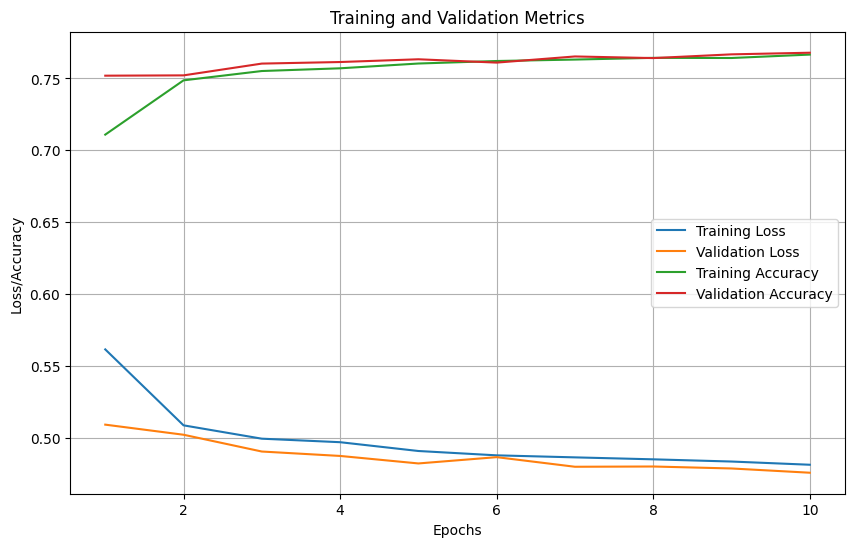

In [21]:
mlp1 = MLP1(embedding_layer, embedding_dim, 256, output_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp1.parameters(), lr=1e-3)

results1 = train_and_validate(mlp1, train_loader, val_loader, criterion, optimizer, device, n_epochs=10)
scores1 = evaluate_model(mlp1, val_loader, device)
plot_metrics(*results1, name='plots/mlp1.png')

Epoch 1:
Train Loss: 0.6009, Train Accuracy: 0.6756
Val Loss: 0.6439, Val Accuracy: 0.6293
Epoch 2:
Train Loss: 0.5484, Train Accuracy: 0.7204
Val Loss: 0.5227, Val Accuracy: 0.7412
Epoch 3:
Train Loss: 0.5342, Train Accuracy: 0.7287
Val Loss: 0.5159, Val Accuracy: 0.7406
Epoch 4:
Train Loss: 0.5357, Train Accuracy: 0.7286
Val Loss: 0.5107, Val Accuracy: 0.7470
Epoch 5:
Train Loss: 0.5234, Train Accuracy: 0.7369
Val Loss: 0.5062, Val Accuracy: 0.7504
Epoch 6:
Train Loss: 0.5226, Train Accuracy: 0.7362
Val Loss: 0.5041, Val Accuracy: 0.7544
Epoch 7:
Train Loss: 0.5205, Train Accuracy: 0.7413
Val Loss: 0.5081, Val Accuracy: 0.7480
Epoch 8:
Train Loss: 0.5331, Train Accuracy: 0.7310
Val Loss: 0.5103, Val Accuracy: 0.7533
Epoch 9:
Train Loss: 0.5212, Train Accuracy: 0.7373
Val Loss: 0.5034, Val Accuracy: 0.7511
Epoch 10:
Train Loss: 0.5160, Train Accuracy: 0.7426
Val Loss: 0.5007, Val Accuracy: 0.7561


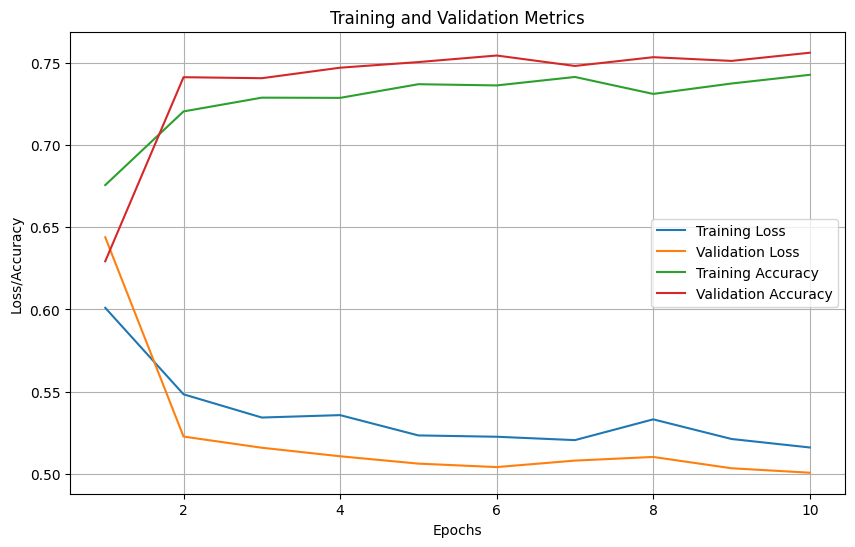

In [22]:
mlp2 = MLP1(embedding_layer, embedding_dim, 256, output_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp2.parameters(), lr=1e-3)

results2 = train_and_validate(mlp2, train_loader2, val_loader2, criterion, optimizer, device, n_epochs=10)
scores2 = evaluate_model(mlp2, val_loader2, device)
plot_metrics(*results2, name='plots/mlp2.png')

Epoch 1:
Train Loss: 0.5506, Train Accuracy: 0.7158
Val Loss: 0.4992, Val Accuracy: 0.7565
Epoch 2:
Train Loss: 0.5062, Train Accuracy: 0.7495
Val Loss: 0.4968, Val Accuracy: 0.7546
Epoch 3:
Train Loss: 0.4972, Train Accuracy: 0.7561
Val Loss: 0.5268, Val Accuracy: 0.7321
Epoch 4:
Train Loss: 0.4943, Train Accuracy: 0.7573
Val Loss: 0.4938, Val Accuracy: 0.7553
Epoch 5:
Train Loss: 0.4917, Train Accuracy: 0.7595
Val Loss: 0.4950, Val Accuracy: 0.7546
Epoch 6:
Train Loss: 0.4907, Train Accuracy: 0.7589
Val Loss: 0.4946, Val Accuracy: 0.7556
Epoch 7:
Train Loss: 0.4870, Train Accuracy: 0.7614
Val Loss: 0.5091, Val Accuracy: 0.7436
Epoch 8:
Train Loss: 0.4860, Train Accuracy: 0.7620
Val Loss: 0.4863, Val Accuracy: 0.7615
Epoch 9:
Train Loss: 0.4847, Train Accuracy: 0.7632
Val Loss: 0.4835, Val Accuracy: 0.7628
Epoch 10:
Train Loss: 0.4821, Train Accuracy: 0.7648
Val Loss: 0.4806, Val Accuracy: 0.7652


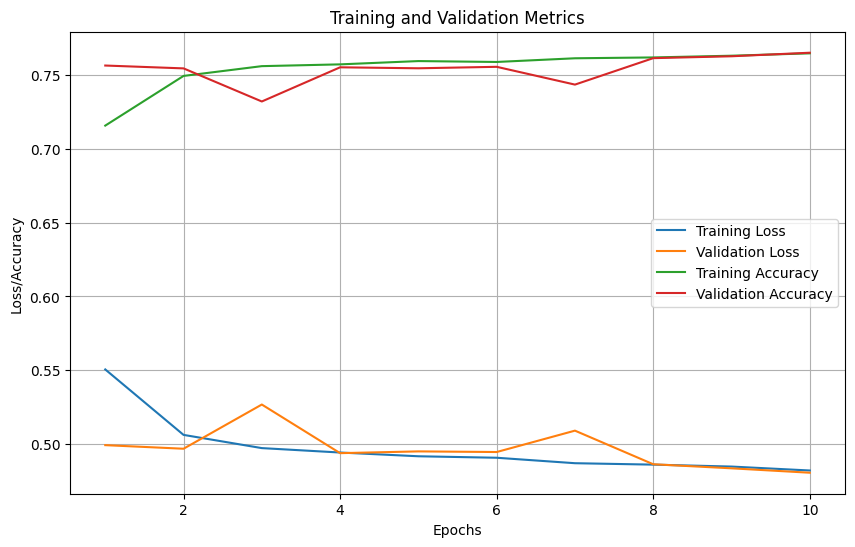

In [23]:
class MLP2(nn.Module):
    def __init__(self, embedding_layer, embedding_dim, h1, h2, output_dim):
        super(MLP2, self).__init__()
        self.embedding = embedding_layer
        self.fc1 = nn.Linear(embedding_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fco = nn.Linear(h2, output_dim)  # Only 1 output neuron

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)  # (batch_size, seq_len, embedding_dim)
        pooled = embedded.mean(dim=1)          # (batch_size, embedding_dim)
        x = torch.relu(self.fc1(pooled))
        x = torch.relu(self.fc2(x))
        output = self.fco(x)
        return output  # No activation here, we apply sigmoid in the loss function

h1, h2 = 128, 64
mlp3 = MLP2(embedding_layer, embedding_dim, h1, h2, output_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp3.parameters(), lr=1e-3)

results3 = train_and_validate(mlp3, train_loader, val_loader, criterion, optimizer, device, n_epochs=10)
scores3 = evaluate_model(mlp3, val_loader, device)
plot_metrics(*results3, name='plots/mlp3.png')

Epoch 1:
Train Loss: 0.5513, Train Accuracy: 0.7128
Val Loss: 0.4984, Val Accuracy: 0.7563
Epoch 2:
Train Loss: 0.5069, Train Accuracy: 0.7495
Val Loss: 0.4896, Val Accuracy: 0.7616
Epoch 3:
Train Loss: 0.4988, Train Accuracy: 0.7545
Val Loss: 0.4912, Val Accuracy: 0.7581
Epoch 4:
Train Loss: 0.4947, Train Accuracy: 0.7572
Val Loss: 0.4985, Val Accuracy: 0.7530
Epoch 5:
Train Loss: 0.4925, Train Accuracy: 0.7582
Val Loss: 0.4943, Val Accuracy: 0.7558
Epoch 6:
Train Loss: 0.4897, Train Accuracy: 0.7603
Val Loss: 0.4832, Val Accuracy: 0.7636
Epoch 7:
Train Loss: 0.4866, Train Accuracy: 0.7626
Val Loss: 0.4839, Val Accuracy: 0.7608
Epoch 8:
Train Loss: 0.4863, Train Accuracy: 0.7629
Val Loss: 0.4879, Val Accuracy: 0.7593
Epoch 9:
Train Loss: 0.4861, Train Accuracy: 0.7622
Val Loss: 0.4791, Val Accuracy: 0.7680
Epoch 10:
Train Loss: 0.4841, Train Accuracy: 0.7640
Val Loss: 0.4760, Val Accuracy: 0.7673


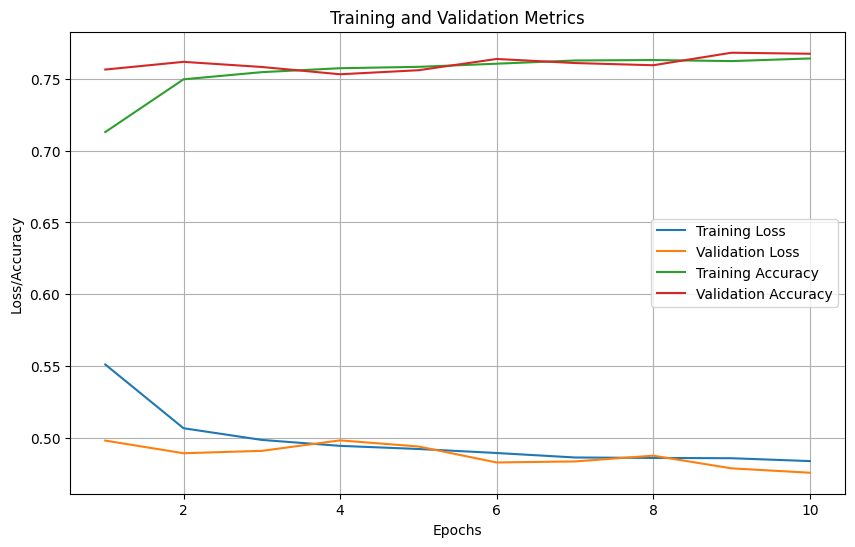

In [24]:
class MLP3(nn.Module):
    def __init__(self, embedding_layer, embedding_dim, h1, h2, h3, output_dim):
        super(MLP3, self).__init__()
        self.embedding = embedding_layer
        self.fc1 = nn.Linear(embedding_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.fco = nn.Linear(h3, output_dim)  # Only 1 output neuron

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)  # (batch_size, seq_len, embedding_dim)
        pooled = embedded.mean(dim=1)          # (batch_size, embedding_dim)
        x = torch.relu(self.fc1(pooled))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        output = self.fco(x)
        return output  # No activation here, we apply sigmoid in the loss function

h1, h2, h3 = 128, 64, 32

mlp4 = MLP3(embedding_layer, embedding_dim, h1, h2, h3, output_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp4.parameters(), lr=1e-3)

results4 = train_and_validate(mlp4, train_loader, val_loader, criterion, optimizer, device, n_epochs=10)
scores4 = evaluate_model(mlp4, val_loader, device)
plot_metrics(*results4, name='plots/mlp4.png')

In [25]:
!pip install optuna
import optuna

def objective(trial):
    # Define the search space for hyperparameters
    num_layers = trial.suggest_int('num_layers', 1, 3)  # Randomly choose number of hidden layers (1 to 3)
    
    # Generate a list of neurons per layer (between 32 and 256)
    hidden_neurons = [trial.suggest_int(f'hidden_neurons_{i}', 32, 256) for i in range(num_layers)]
    
    # Learning rate search space
    learning_rate = trial.suggest_loguniform('lr', 1e-5, 1e-1)
    
    # Model instantiation based on the number of layers
    if num_layers == 1:
        h1 = hidden_neurons[0]
        mlp_model = MLP1(embedding_layer, embedding_dim, h1, output_dim).to(device)
    elif num_layers == 2:
        h1, h2 = hidden_neurons
        mlp_model = MLP2(embedding_layer, embedding_dim, h1, h2, output_dim).to(device)
    elif num_layers == 3:
        h1, h2, h3 = hidden_neurons
        mlp_model = MLP3(embedding_layer, embedding_dim, h1, h2, h3, output_dim).to(device)
    mlp_model = mlp_model.to(device)
    
    # Optimizer and Loss function
    optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    print(device, next(mlp_model.parameters()).device)
    # Training and validation process (train_and_validate function should return losses)
    train_losses, val_losses, train_accuracies, val_accuracies = train_and_validate(
        mlp_model, train_loader, val_loader, criterion, optimizer, device, n_epochs=10
    )
    
    return val_losses[-1]


# Create a study object and optimize the objective function
study = optuna.create_study(direction='minimize')  # We want to minimize validation loss
study.optimize(objective, n_trials=20, n_jobs=1)  # 20 trials

[I 2025-04-30 22:29:12,236] A new study created in memory with name: no-name-f9f0b82d-2daa-4d4f-b5a5-6418f8808f34
/tmp/ipykernel_19/546823180.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('lr', 1e-5, 1e-1)


cuda cuda:0
Epoch 1:
Train Loss: 0.5455, Train Accuracy: 0.7225
Val Loss: 0.5196, Val Accuracy: 0.7417
Epoch 2:
Train Loss: 0.5123, Train Accuracy: 0.7470
Val Loss: 0.4948, Val Accuracy: 0.7606
Epoch 3:
Train Loss: 0.5069, Train Accuracy: 0.7509
Val Loss: 0.4919, Val Accuracy: 0.7622
Epoch 4:
Train Loss: 0.5023, Train Accuracy: 0.7542
Val Loss: 0.5002, Val Accuracy: 0.7537
Epoch 5:
Train Loss: 0.5009, Train Accuracy: 0.7546
Val Loss: 0.5053, Val Accuracy: 0.7482
Epoch 6:
Train Loss: 0.4973, Train Accuracy: 0.7560
Val Loss: 0.4884, Val Accuracy: 0.7627
Epoch 7:
Train Loss: 0.5008, Train Accuracy: 0.7530
Val Loss: 0.5044, Val Accuracy: 0.7471
Epoch 8:
Train Loss: 0.4971, Train Accuracy: 0.7565
Val Loss: 0.4987, Val Accuracy: 0.7535
Epoch 9:
Train Loss: 0.4956, Train Accuracy: 0.7576
Val Loss: 0.4932, Val Accuracy: 0.7592


[I 2025-04-30 22:32:52,777] Trial 0 finished with value: 0.48630280110491325 and parameters: {'num_layers': 1, 'hidden_neurons_0': 80, 'lr': 0.013643369090283389}. Best is trial 0 with value: 0.48630280110491325.


Epoch 10:
Train Loss: 0.4942, Train Accuracy: 0.7580
Val Loss: 0.4863, Val Accuracy: 0.7625
cuda cuda:0


/tmp/ipykernel_19/546823180.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('lr', 1e-5, 1e-1)


...

Epoch 10:
Train Loss: 0.4838, Train Accuracy: 0.7637
Val Loss: 0.4790, Val Accuracy: 0.7668
cuda cuda:0


/tmp/ipykernel_19/546823180.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('lr', 1e-5, 1e-1)


Epoch 1:
Train Loss: 0.5531, Train Accuracy: 0.7114
Val Loss: 0.5016, Val Accuracy: 0.7542
Epoch 2:
Train Loss: 0.5050, Train Accuracy: 0.7490
Val Loss: 0.4929, Val Accuracy: 0.7592
Epoch 3:
Train Loss: 0.4972, Train Accuracy: 0.7559
Val Loss: 0.5018, Val Accuracy: 0.7498
Epoch 4:
Train Loss: 0.4966, Train Accuracy: 0.7558
Val Loss: 0.4888, Val Accuracy: 0.7597
Epoch 5:
Train Loss: 0.4913, Train Accuracy: 0.7598
Val Loss: 0.4909, Val Accuracy: 0.7595
Epoch 6:
Train Loss: 0.4904, Train Accuracy: 0.7594
Val Loss: 0.4813, Val Accuracy: 0.7650
Epoch 7:
Train Loss: 0.4881, Train Accuracy: 0.7611
Val Loss: 0.4794, Val Accuracy: 0.7659
Epoch 8:
Train Loss: 0.4873, Train Accuracy: 0.7609
Val Loss: 0.4808, Val Accuracy: 0.7641
Epoch 9:
Train Loss: 0.4858, Train Accuracy: 0.7629
Val Loss: 0.4808, Val Accuracy: 0.7644


[I 2025-04-30 23:42:58,137] Trial 19 finished with value: 0.47670701648815567 and parameters: {'num_layers': 3, 'hidden_neurons_0': 91, 'hidden_neurons_1': 85, 'hidden_neurons_2': 39, 'lr': 0.0010319450318984579}. Best is trial 16 with value: 0.47439056060400353.


Epoch 10:
Train Loss: 0.4838, Train Accuracy: 0.7636
Val Loss: 0.4767, Val Accuracy: 0.7671


Best hyperparameters: {'num_layers': 3, 'hidden_neurons_0': 108, 'hidden_neurons_1': 102, 'hidden_neurons_2': 253, 'lr': 0.0018493099612535298}
Epoch 1:
Train Loss: 0.5387, Train Accuracy: 0.7227
Val Loss: 0.5205, Val Accuracy: 0.7362
Epoch 2:
Train Loss: 0.5070, Train Accuracy: 0.7483
Val Loss: 0.4989, Val Accuracy: 0.7536
Epoch 3:
Train Loss: 0.5005, Train Accuracy: 0.7536
Val Loss: 0.4898, Val Accuracy: 0.7611
Epoch 4:
Train Loss: 0.4976, Train Accuracy: 0.7542
Val Loss: 0.4855, Val Accuracy: 0.7638
Epoch 5:
Train Loss: 0.4947, Train Accuracy: 0.7568
Val Loss: 0.4813, Val Accuracy: 0.7640
Epoch 6:
Train Loss: 0.4903, Train Accuracy: 0.7599
Val Loss: 0.4800, Val Accuracy: 0.7656
Epoch 7:
Train Loss: 0.4866, Train Accuracy: 0.7617
Val Loss: 0.4827, Val Accuracy: 0.7625
Epoch 8:
Train Loss: 0.4847, Train Accuracy: 0.7644
Val Loss: 0.4834, Val Accuracy: 0.7609
Epoch 9:
Train Loss: 0.4848, Train Accuracy: 0.7636
Val Loss: 0.4761, Val Accuracy: 0.7686
Epoch 10:
Train Loss: 0.4829, Train A

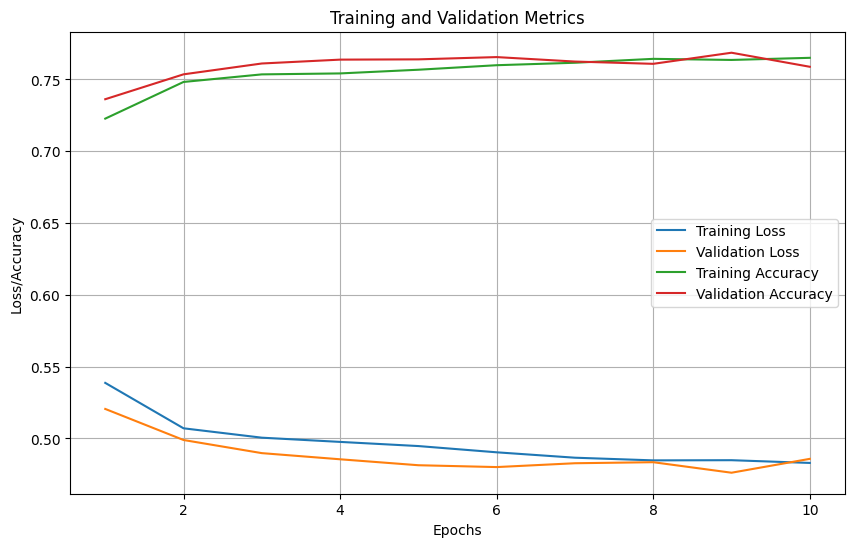

In [26]:
# Get the best hyperparameters from the Optuna study
best_params = study.best_params
print(f"Best hyperparameters: {best_params}")

# Number of layers
num_layers = best_params['num_layers']

# Hidden layer neurons
hidden_neurons = [best_params[f'hidden_neurons_{i}'] for i in range(num_layers)]

# Learning rate
learning_rate = best_params['lr']

# Instantiate the best model based on the best hyperparameters
if num_layers == 1:
    h1 = hidden_neurons[0]
    best_mlp_model = MLP1(embedding_layer, embedding_dim, h1, output_dim).to(device)
elif num_layers == 2:
    h1, h2 = hidden_neurons
    best_mlp_model = MLP2(embedding_layer, embedding_dim, h1, h2, output_dim).to(device)
elif num_layers == 3:
    h1, h2, h3 = hidden_neurons
    best_mlp_model = MLP3(embedding_layer, embedding_dim, h1, h2, h3, output_dim).to(device)

# Optimizer and loss function for the best model
optimizer = optim.Adam(best_mlp_model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()

# Train the best model
results_best = train_and_validate(best_mlp_model, train_loader, val_loader, criterion, optimizer, device, n_epochs=10)

# Evaluate and plot
scores_best = evaluate_model(best_mlp_model, val_loader, device)
plot_metrics(*results_best, name='plots/best_mlp.png')

In [27]:
from sklearn.metrics import classification_report

_, y_true1, y_pred1, y_prob1 = scores1
print(classification_report(y_true1, y_pred1))

_, y_true2, y_pred2, y_prob2 = scores2
print(classification_report(y_true2, y_pred2))

_, y_true3, y_pred3, y_prob3 = scores3
print(classification_report(y_true3, y_pred3))

_, y_true4, y_pred4, y_prob4 = scores4
print(classification_report(y_true4, y_pred4))

_, y_true5, y_pred5, y_prob5 = scores_best
print(classification_report(y_true5, y_pred5))

              precision    recall  f1-score   support

           0       0.75      0.80      0.77     21197
           1       0.78      0.74      0.76     21199

    accuracy                           0.77     42396
   macro avg       0.77      0.77      0.77     42396
weighted avg       0.77      0.77      0.77     42396

              precision    recall  f1-score   support

           0       0.75      0.77      0.76     21197
           1       0.76      0.74      0.75     21199

    accuracy                           0.76     42396
   macro avg       0.76      0.76      0.76     42396
weighted avg       0.76      0.76      0.76     42396

              precision    recall  f1-score   support

           0       0.78      0.74      0.76     21197
           1       0.75      0.79      0.77     21199

    accuracy                           0.77     42396
   macro avg       0.77      0.77      0.77     42396
weighted avg       0.77      0.77      0.77     42396

              preci

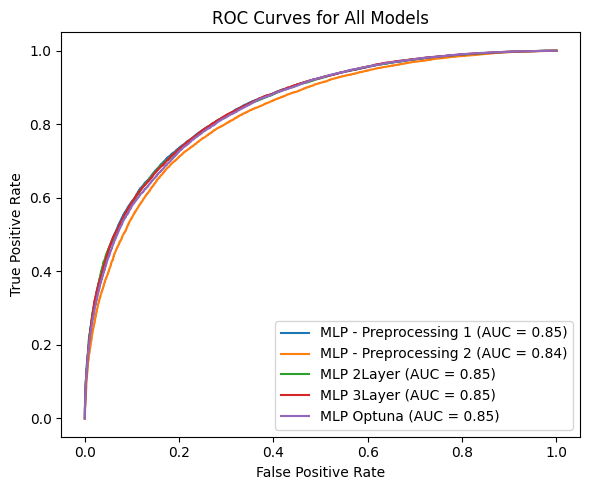

In [28]:
from sklearn.metrics import roc_curve, auc

# Generate ROC curves
plt.figure(figsize=(6, 5))



fpr1, tpr1, _ = roc_curve(y_true1, y_prob1)
auc1 = auc(fpr1, tpr1)
plt.plot(fpr1, tpr1, label=f'MLP - Preprocessing 1 (AUC = {auc1:.2f})')

fpr2, tpr2, _ = roc_curve(y_true2, y_prob2)
auc2 = auc(fpr2, tpr2)
plt.plot(fpr2, tpr2, label=f'MLP - Preprocessing 2 (AUC = {auc2:.2f})')


fpr3, tpr3, _ = roc_curve(y_true3, y_prob3)
auc3 = auc(fpr3, tpr3)
plt.plot(fpr3, tpr3, label=f'MLP 2Layer (AUC = {auc3:.2f})')


fpr4, tpr4, _ = roc_curve(y_true4, y_prob4)
auc4 = auc(fpr4, tpr4)
plt.plot(fpr4, tpr4, label=f'MLP 3Layer (AUC = {auc4:.2f})')


fpr5, tpr5, _ = roc_curve(y_true5, y_prob5)
auc5 = auc(fpr5, tpr5)
plt.plot(fpr5, tpr5, label=f'MLP Optuna (AUC = {auc5:.2f})')

# Plot settings
# plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=300)
plt.show()

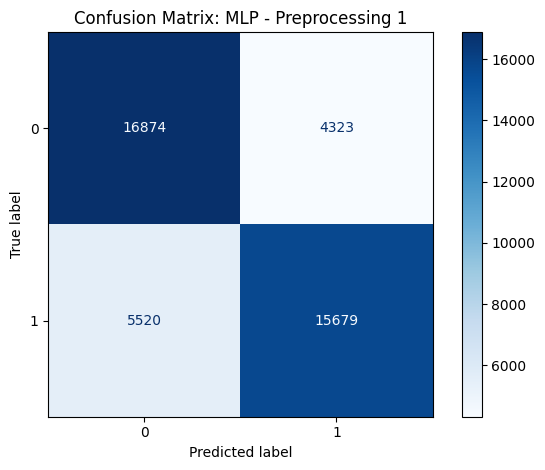

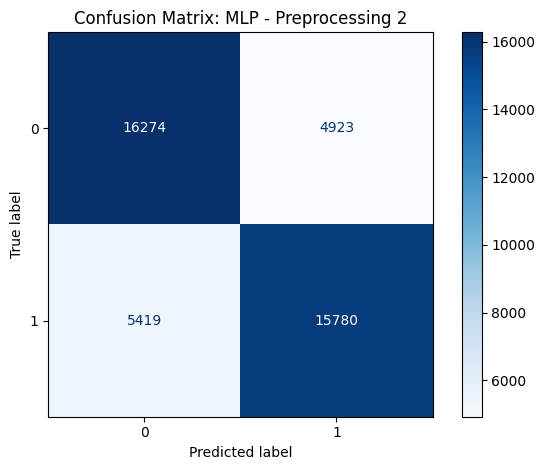

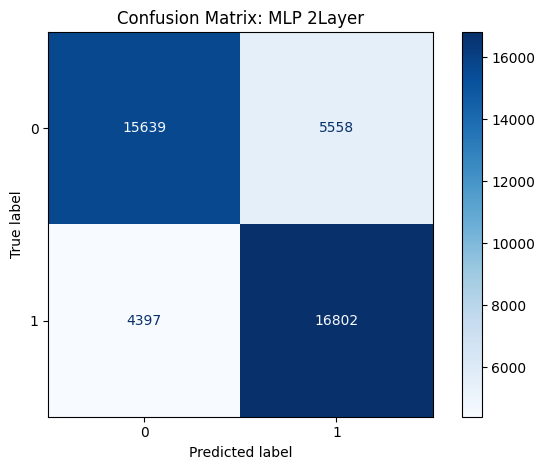

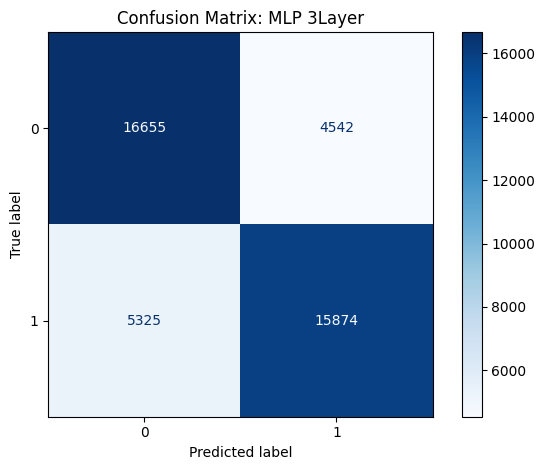

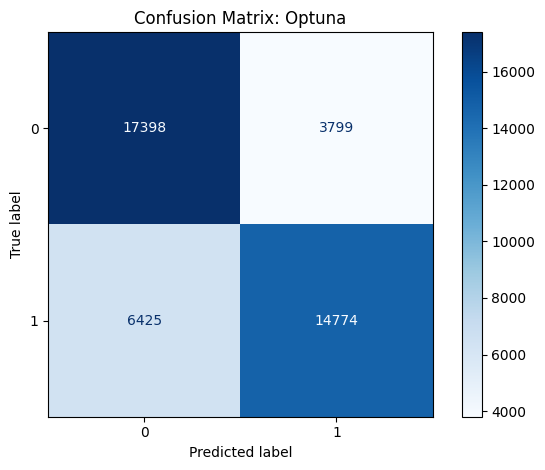

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# Plot and save confusion matrices for all models
plot_confusion_matrix(y_true1, y_pred1, 'Confusion Matrix: MLP - Preprocessing 1', 'plots/confusion_matrix_mlp1.png')
plot_confusion_matrix(y_true2, y_pred2, 'Confusion Matrix: MLP - Preprocessing 2', 'plots/confusion_matrix_mlp2.png')
plot_confusion_matrix(y_true3, y_pred3, 'Confusion Matrix: MLP 2Layer', 'plots/mlp3.png')
plot_confusion_matrix(y_true4, y_pred4, 'Confusion Matrix: MLP 3Layer', 'plots/mlp4.png')
plot_confusion_matrix(y_true5, y_pred5, 'Confusion Matrix: Optuna', 'plots/mlp5.png')

In [30]:
def get_accuracy(scores):
  _, y_true, y_pred, _ = scores
  return accuracy_score(y_true,y_pred)

models_accuracy = {
    'MLP1': get_accuracy(scores1),
    'MLP2': get_accuracy(scores2),
    'MLP3': get_accuracy(scores3),
    'MLP4': get_accuracy(scores4),
    'MLP_Optuna': get_accuracy(scores_best),
}

models_by_name = {
    'MLP1': mlp1,
    'MLP2': mlp2,
    'MLP3': mlp3,
    'MLP4': mlp4,
    'MLP_Optuna': best_mlp_model,
}


best_model_name = max(models_accuracy, key=models_accuracy.get)
print(f"The best model is {best_model_name} with accuracy {models_accuracy[best_model_name]:.4f}")

The best model is MLP1 with accuracy 0.7678


In [31]:
best_model = models_by_name[best_model_name]
if 'MLP2' == best_model_name:
    test_dataset = TweetDataset(test_data['Clean2'], [0] * len(test_data), word_to_idx) # Placeholder labels
else:
    test_dataset = TweetDataset(test_data['Clean'], [0] * len(test_data), word_to_idx) # Placeholder labels
test_loader = DataLoader(test_dataset, batch_size=256, collate_fn=pad_batch, shuffle=False)

best_model.eval()
predictions = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        probabilities = torch.sigmoid(outputs.squeeze())
        predicted_labels = (probabilities > 0.5).int().cpu().numpy().tolist()
        predictions.extend(predicted_labels)

submission_df = pd.DataFrame({'ID': test_data['ID'], 'Label': predictions})
submission_df.to_csv('submission.csv', index=False)